# Activity 1 — Descriptive Analytics
**Course:** Data Analytics (10204210) | **Dataset:** Emergency Response

Techniques applied:
- Measures of Frequency
- Measures of Central Tendency
- Measures of Dispersion
- Measures of Position
- Outlier Detection (Z-Score and IQR)
- Visualizations (single and multi-column)
- Correlation Heatmap
- Contingency Table
- Time Series: SMA and EMA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
%matplotlib inline

In [ ]:
# Load the cleaned dataset saved from Phase 0
df = pd.read_csv('df_clean.csv', parse_dates=['Timestamp'])

# Take a 2-year subset (2018-2019) for focused analysis
df = df[df['Year'].isin([2018, 2019])].copy()
df.reset_index(drop=True, inplace=True) #reset_index(drop=True) renumbers rows 0,1,2… after filtering (and drop=True discards the old index).

print('Dataset shape:', df.shape)
print('Date range:', df['Timestamp'].min().date(), '->', df['Timestamp'].max().date())
df.head()

Dataset shape: (105120, 22)
Date range: 2018-01-01 -> 2019-12-31


,Timestamp,Incident_Severity,Incident_Type,Region_Type,Traffic_Congestion,Weather_Condition,Ambulance_Availability,Hospital_Capacity,Distance_to_Incident,Number_of_Injuries,...,Emergency_Level,Ambulance_Speed,Fuel_Level,Weather_Impact,Dispatch_Coordinator,Response_Time,Year,Month,Hour,DayOfWeek
0,2018-01-01 00:00:00,Low,Cardiac Arrest,Suburban,High,Clear,Available,91,8.89,1,...,Major,43.549849,90.030756,Severe,AI,20.870220,2018,1,0,Monday
1,2018-01-01 00:10:00,Low,Other,Urban,Moderate,Clear,Available,28,28.10,2,...,Critical,30.687975,88.255008,Moderate,Human,24.486195,2018,1,0,Monday
2,2018-01-01 00:20:00,Medium,Cardiac Arrest,Suburban,High,Rainy,Available,83,40.43,1,...,Minor,44.456331,97.719622,No Impact,Human,18.760740,2018,1,0,Monday
3,2018-01-01 00:30:00,Low,Accident,Urban,Moderate,Clear,Available,31,18.97,3,...,Minor,35.879968,60.234672,No Impact,Human,18.169534,2018,1,0,Monday
4,2018-01-01 00:40:00,Low,Cardiac Arrest,Urban,Moderate,Stormy,Available,52,16.31,3,...,Minor,26.369383,71.083564,Moderate,Human,5.000000,2018,1,0,Monday


## 1. Measures of Frequency

In [3]:
# Frequency of Incident Severity
print('Incident Severity Frequency:')
print(df['Incident_Severity'].value_counts())
print()

# Relative frequency (percentage)
print('Relative Frequency (%):')
print((df['Incident_Severity'].value_counts() / len(df) * 100).round(2))

Incident Severity Frequency:
Incident_Severity
Low       63058
Medium    31451
High      10611
Name: count, dtype: int64

Relative Frequency (%):
Incident_Severity
Low       59.99
Medium    29.92
High      10.09
Name: count, dtype: float64


In [4]:
# Frequency of other key categorical columns
for col in ['Region_Type', 'Traffic_Congestion', 'Weather_Condition', 'Incident_Type']:
    print(f'\n{col}:')
    print(df[col].value_counts())


Region_Type:
Region_Type
Urban       73600
Suburban    21088
Rural       10432
Name: count, dtype: int64

Traffic_Congestion:
Traffic_Congestion
Low         52393
Moderate    42071
High        10656
Name: count, dtype: int64

Weather_Condition:
Weather_Condition
Clear     84211
Rainy     15699
Stormy     5210
Name: count, dtype: int64

Incident_Type:
Incident_Type
Accident          52652
Cardiac Arrest    21143
Other             21039
Fire              10286
Name: count, dtype: int64


In [ ]:
# Grouped frequency: Incident Type by Region Type
#groupby() groups the data by 'Incident_Type' and 'Region_Type', 
# and then counts the number of occurrences in each group using count().
grouped = df.groupby(['Incident_Type', 'Region_Type'])['Incident_Type'].count() 
print('Incidents by Type and Region:')
print(grouped)

Incidents by Type and Region:
Incident_Type   Region_Type
Accident        Rural           5201
                Suburban       10580
                Urban          36871
Cardiac Arrest  Rural           2140
                Suburban        4135
                Urban          14868
Fire            Rural           1007
                Suburban        2103
                Urban           7176
Other           Rural           2084
                Suburban        4270
                Urban          14685
Name: Incident_Type, dtype: int64


## 2. Measures of Central Tendency

In [ ]:
# Mean, Median, Mode for numeric columns
numeric_cols = ['Response_Time', 'Distance_to_Incident', 'Number_of_Injuries',
                'Ambulance_Speed', 'Fuel_Level', 'Hospital_Capacity']

print('Mean:')
print(df[numeric_cols].mean().round(4)) # sum ÷ count (sensitive to outliers).

print('\nMedian:')
print(df[numeric_cols].median().round(4)) #the middle value when sorted (robust)

print('\nMode:')
print(df[numeric_cols].mode().iloc[0].round(4)) #the most frequent value (can be multiple, but we take the first one with iloc[0])

Mean:
Response_Time           15.0701
Distance_to_Incident    25.4632
Number_of_Injuries       1.5199
Ambulance_Speed         40.0134
Fuel_Level              69.9142
Hospital_Capacity       54.5054
dtype: float64

Median:
Response_Time           15.0335
Distance_to_Incident    25.4400
Number_of_Injuries       1.0000
Ambulance_Speed         39.9802
Fuel_Level              70.0868
Hospital_Capacity       55.0000
dtype: float64

Mode:
Response_Time             5.00
Distance_to_Incident     37.22
Number_of_Injuries        1.00
Ambulance_Speed          20.00
Fuel_Level              100.00
Hospital_Capacity        99.00
Name: 0, dtype: float64


## 3. Measures of Dispersion

In [ ]:
# Range, Variance, Standard Deviation
print('Range (Max - Min):')
print((df[numeric_cols].max() - df[numeric_cols].min()).round(4)) # max - min (sensitive to outliers)

print('\nVariance:')
print(df[numeric_cols].var().round(4)) #average squared distance from the mean (It measures how spread out the data is, but in squared units (hard to interpret).)

print('\nStandard Deviation:')
print(df[numeric_cols].std().round(4)) # √variance, in the same units as the data (so interpretable, measure of spread.)

Range (Max - Min):
Response_Time           25.0000
Distance_to_Incident    49.0000
Number_of_Injuries       3.0000
Ambulance_Speed         54.4237
Fuel_Level              90.0000
Hospital_Capacity       89.0000
dtype: float64

Variance:
Response_Time            23.8745
Distance_to_Incident    199.9706
Number_of_Injuries        0.5278
Ambulance_Speed          63.6063
Fuel_Level              215.3603
Hospital_Capacity       677.1655
dtype: float64

Standard Deviation:
Response_Time            4.8862
Distance_to_Incident    14.1411
Number_of_Injuries       0.7265
Ambulance_Speed          7.9754
Fuel_Level              14.6752
Hospital_Capacity       26.0224
dtype: float64


In [ ]:
# Coefficient of Variation (CV) = Std / Mean * 100
cv = (df[numeric_cols].std() / df[numeric_cols].mean() * 100).round(2) #std ÷ mean × 100. It makes spread comparable across different units/scales (a %).
print('Coefficient of Variation (%):')
print(cv)

#Distance_to_Incident has the highest CV (55.5%) → it's the most variable/unpredictable factor. 
# Decision: pre-positioning ambulances closer 
# to demand hotspots would cut this variability and tighten response times.

Coefficient of Variation (%):
Response_Time           32.42
Distance_to_Incident    55.54
Number_of_Injuries      47.80
Ambulance_Speed         19.93
Fuel_Level              20.99
Hospital_Capacity       47.74
dtype: float64


## 4. Measures of Position

In [ ]:
# Percentiles; tell you what percentage of data falls below a certain value
percentiles = np.percentile(df['Response_Time'], [10, 25, 50, 75, 90]) 
print('Response_Time Percentiles:')
print('10th Percentile:', round(percentiles[0], 4))
print('25th Percentile:', round(percentiles[1], 4))
print('50th Percentile:', round(percentiles[2], 4))
print('75th Percentile:', round(percentiles[3], 4))
print('90th Percentile:', round(percentiles[4], 4))

Response_Time Percentiles:
10th Percentile: 8.6818
25th Percentile: 11.6625
50th Percentile: 15.0335
75th Percentile: 18.3861
90th Percentile: 21.4405


P90 = 21.44 min becomes a data-driven SLA target ("Service Level Agreement") instead of a guessed number.

In [ ]:
# Quartiles and IQR for all numeric columns
q1 = df[numeric_cols].quantile(0.25) #Q1 (25th)
q3 = df[numeric_cols].quantile(0.75) #Q3 (75th)
iqr = q3 - q1 #Middle 50% of data

print('Q1 (25th percentile):')
print(q1.round(4))
print('\nQ3 (75th percentile):')
print(q3.round(4))
print('\nIQR (Q3 - Q1):')
print(iqr.round(4))

Q1 (25th percentile):
Response_Time           11.6625
Distance_to_Incident    13.2000
Number_of_Injuries       1.0000
Ambulance_Speed         34.5823
Fuel_Level              59.9322
Hospital_Capacity       32.0000
Name: 0.25, dtype: float64

Q3 (75th percentile):
Response_Time           18.3861
Distance_to_Incident    37.6900
Number_of_Injuries       2.0000
Ambulance_Speed         45.4036
Fuel_Level              80.1360
Hospital_Capacity       77.0000
Name: 0.75, dtype: float64

IQR (Q3 - Q1):
Response_Time            6.7237
Distance_to_Incident    24.4900
Number_of_Injuries       1.0000
Ambulance_Speed         10.8214
Fuel_Level              20.2038
Hospital_Capacity       45.0000
dtype: float64


Insight 1: Distance is Highly Variable
Distance to incident shows the highest variability among operational factors (IQR=24.49 km), suggesting emergencies occur across a wide geographical area. This justifies the need for strategic ambulance placement.

Insight 2: Hospital Capacity is Extremely Inconsistent
Hospital capacity varies dramatically (IQR=45%), with some hospitals at 32% capacity while others at 77%. This significant variability should be considered in dispatch decisions to avoid sending patients to overwhelmed hospitals

Insight 3: Injuries are Usually Low
75% of incidents have 2 or fewer injuries, indicating that most emergencies are relatively minor. Major incidents with multiple injuries are rare but require special attention



## 5. Outlier Detection

In [ ]:
# Z-Score method — outliers where |Z| > 3
#(value − mean) ÷ std → how many standard deviations a point is from the mean.
df['RT_zscore'] = zscore(df['Response_Time'])
outliers_zscore = df[np.abs(df['RT_zscore']) > 3] #
print('Outliers detected by Z-Score method:', len(outliers_zscore))
print(outliers_zscore[['Response_Time', 'RT_zscore']].head())

Outliers detected by Z-Score method: 184
      Response_Time  RT_zscore
1053           30.0   3.055562
2021           30.0   3.055562
2580           30.0   3.055562
2642           30.0   3.055562
2710           30.0   3.055562


In [12]:
# IQR method
q1_rt = df['Response_Time'].quantile(0.25)
q3_rt = df['Response_Time'].quantile(0.75)
iqr_rt = q3_rt - q1_rt

lower_bound = q1_rt - 1.5 * iqr_rt
upper_bound = q3_rt + 1.5 * iqr_rt

outliers_iqr = df[(df['Response_Time'] < lower_bound) | (df['Response_Time'] > upper_bound)]
print(f'Lower Bound: {lower_bound:.4f}')
print(f'Upper Bound: {upper_bound:.4f}')
print(f'Outliers detected by IQR method: {len(outliers_iqr)}')

Lower Bound: 1.5770
Upper Bound: 28.4716
Outliers detected by IQR method: 381


Z-score assumes roughly normal data and uses mean/std (themselves outlier-sensitive). IQR is distribution-free and more robust, so it flags more (381 > 184). Showing both demonstrates methodological breadth.

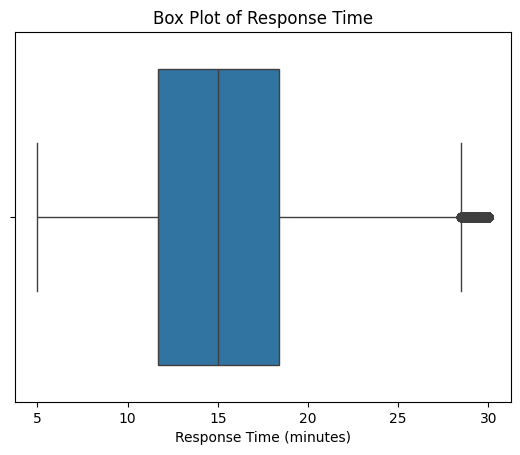

In [13]:
# Box plot — shows outliers visually
sns.boxplot(x=df['Response_Time'])
plt.title('Box Plot of Response Time')
plt.xlabel('Response Time (minutes)')
plt.show()

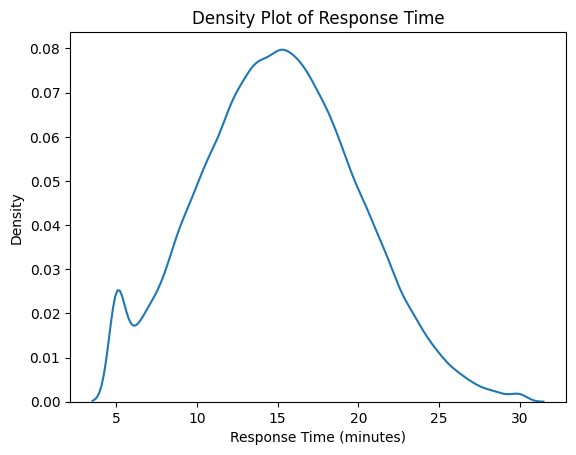

In [14]:
# Density plot
sns.kdeplot(df['Response_Time'])
plt.title('Density Plot of Response Time')
plt.xlabel('Response Time (minutes)')
plt.show()

## 6. Visualizations — Single Column

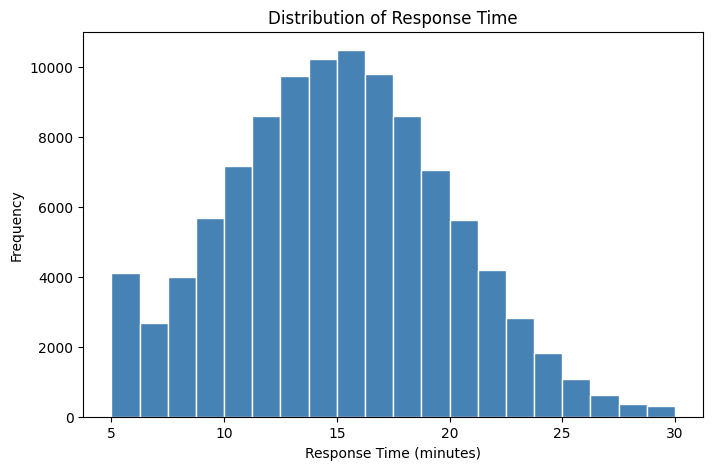

In [15]:
# Histogram: Response Time
plt.figure(figsize=(8, 5))
plt.hist(df['Response_Time'], bins=20, color='steelblue', edgecolor='white')
plt.title('Distribution of Response Time')
plt.xlabel('Response Time (minutes)')
plt.ylabel('Frequency')
plt.show()

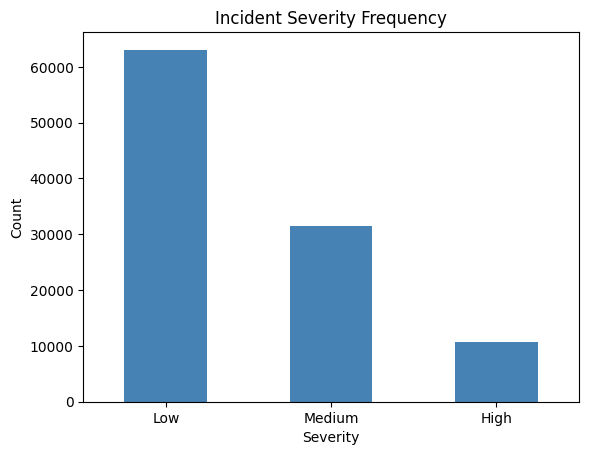

In [16]:
# Bar Chart: Incident Severity
df['Incident_Severity'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Incident Severity Frequency')
plt.xlabel('Severity')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

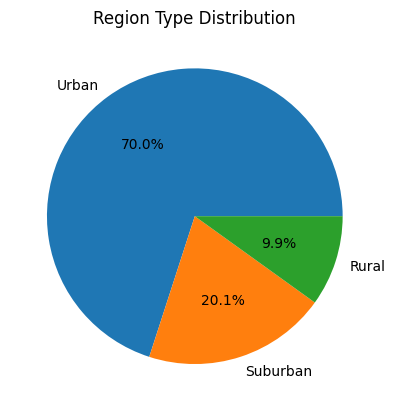

In [17]:
# Pie Chart: Region Type
df['Region_Type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Region Type Distribution')
plt.ylabel('')
plt.show()

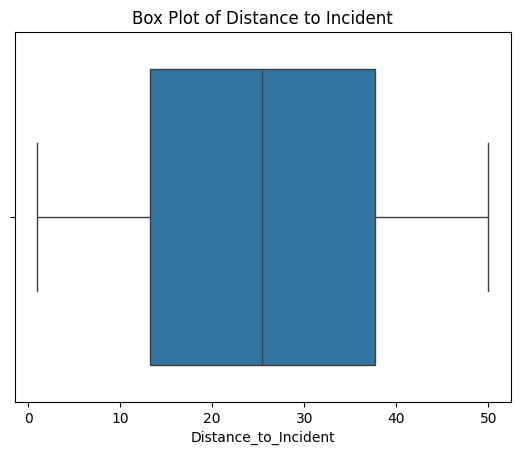

In [18]:
# Box Plot: Distance to Incident
sns.boxplot(x=df['Distance_to_Incident'])
plt.title('Box Plot of Distance to Incident')
plt.show()

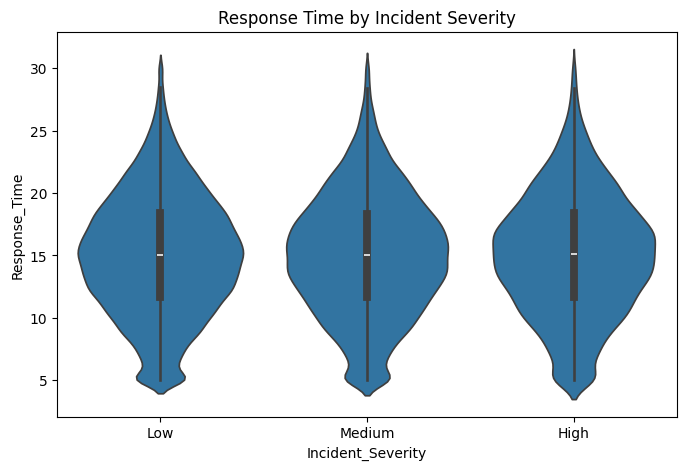

In [19]:
# Violin Plot: Response Time by Incident Severity
plt.figure(figsize=(8, 5))
sns.violinplot(x='Incident_Severity', y='Response_Time', data=df)
plt.title('Response Time by Incident Severity')
plt.show()

## 7. Visualizations — Multi Column

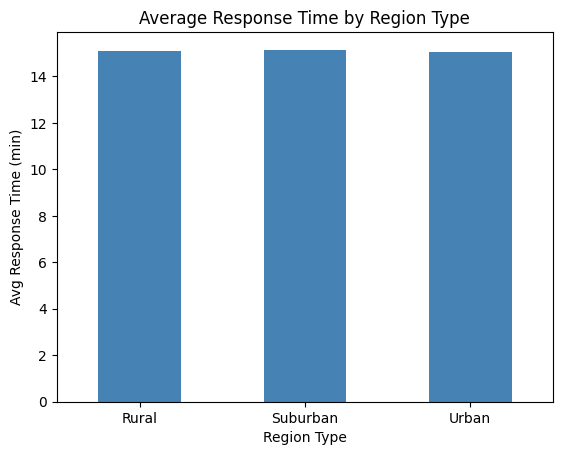

In [20]:
# Bar Chart: Average Response Time by Region Type
df.groupby('Region_Type')['Response_Time'].mean().plot(kind='bar', color='steelblue')
plt.title('Average Response Time by Region Type')
plt.xlabel('Region Type')
plt.ylabel('Avg Response Time (min)')
plt.xticks(rotation=0)
plt.show()

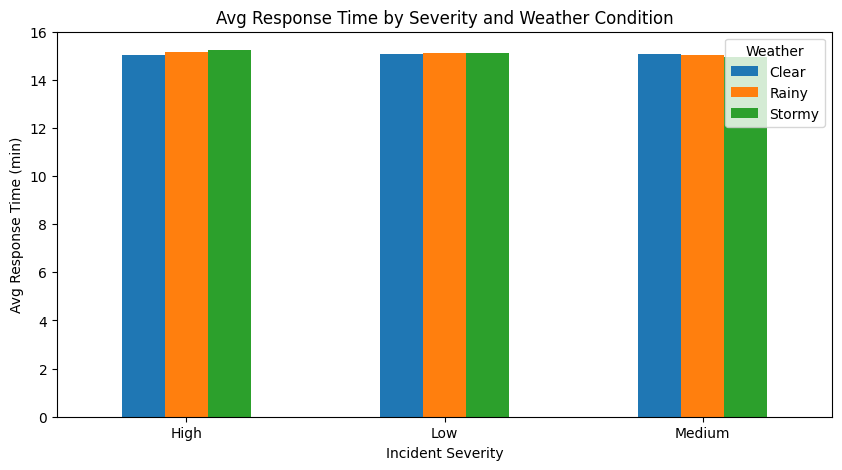

In [21]:
# Grouped Bar: Average Response Time by Severity and Weather
pivot_bar = df.pivot_table(values='Response_Time', index='Incident_Severity',
                           columns='Weather_Condition', aggfunc='mean')
pivot_bar.plot(kind='bar', figsize=(10, 5))
plt.title('Avg Response Time by Severity and Weather Condition')
plt.xlabel('Incident Severity')
plt.ylabel('Avg Response Time (min)')
plt.xticks(rotation=0)
plt.legend(title='Weather')
plt.show()

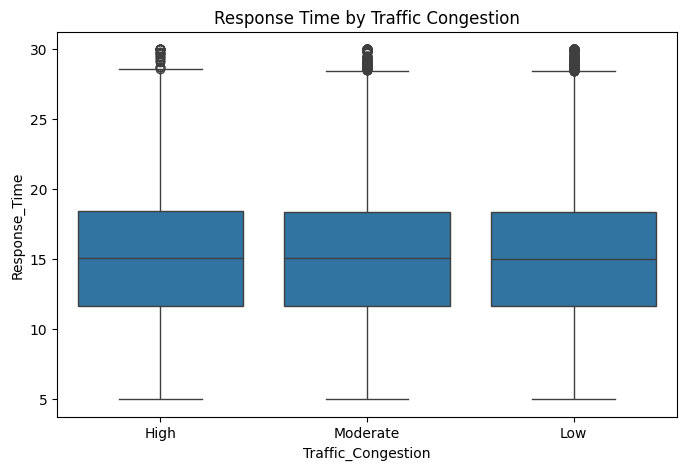

In [22]:
# Box Plot: Response Time by Traffic Congestion
plt.figure(figsize=(8, 5))
sns.boxplot(x='Traffic_Congestion', y='Response_Time', data=df)
plt.title('Response Time by Traffic Congestion')
plt.show()

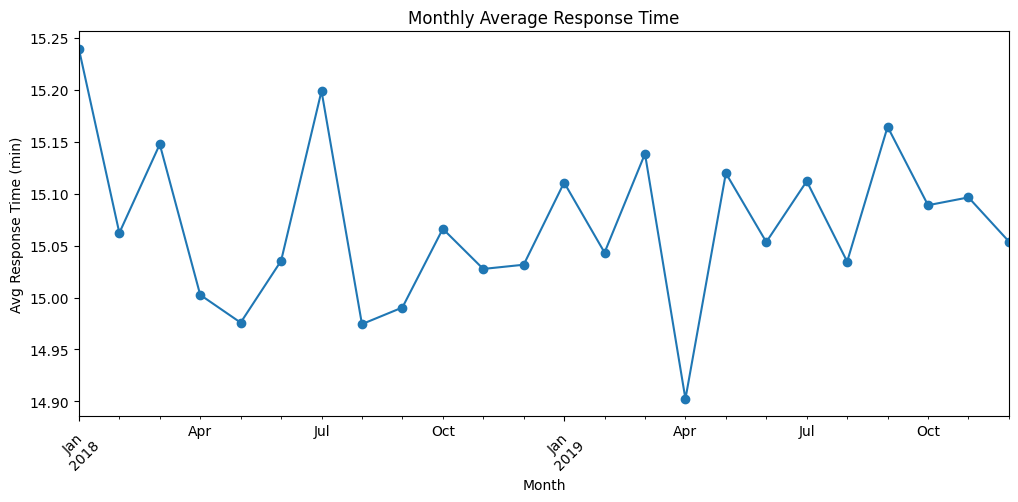

In [23]:
# Line Chart: Monthly Average Response Time
df['YearMonth'] = df['Timestamp'].dt.to_period('M')
monthly_rt = df.groupby('YearMonth')['Response_Time'].mean()

plt.figure(figsize=(12, 5))
monthly_rt.plot(kind='line', marker='o')
plt.title('Monthly Average Response Time')
plt.xlabel('Month')
plt.ylabel('Avg Response Time (min)')
plt.xticks(rotation=45)
plt.show()

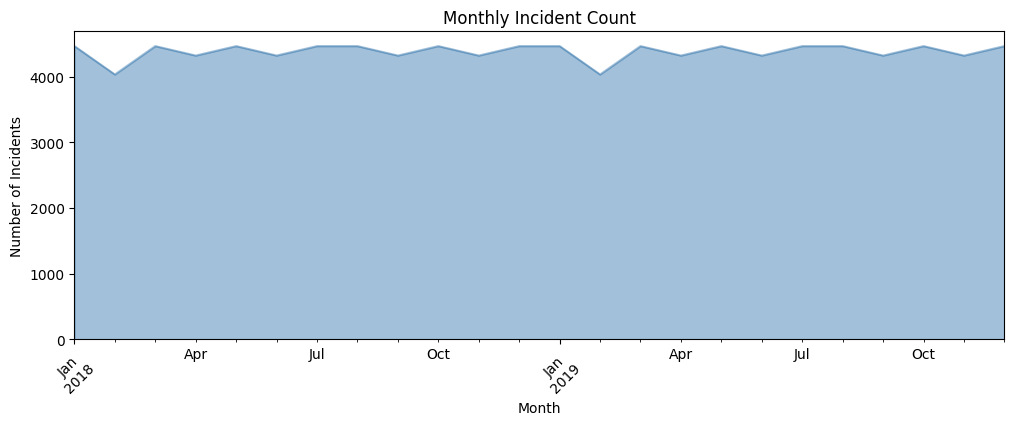

In [24]:
# Area Chart: Monthly incident count
monthly_count = df.groupby('YearMonth')['Response_Time'].count()
plt.figure(figsize=(12, 4))
monthly_count.plot(kind='area', alpha=0.5, color='steelblue')
plt.title('Monthly Incident Count')
plt.xlabel('Month')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.show()

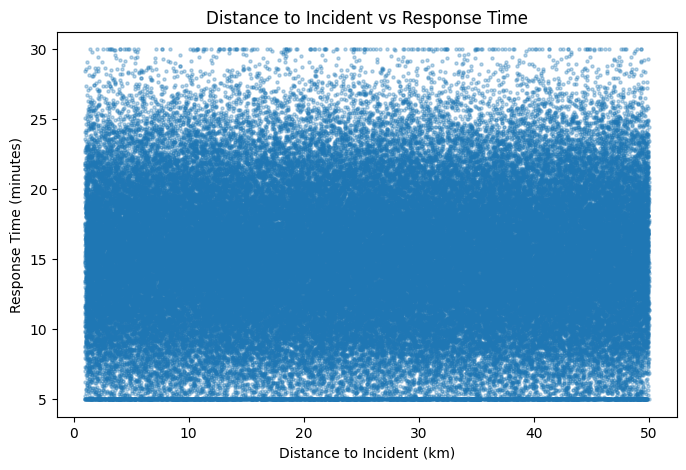

In [25]:
# Scatter Plot: Distance to Incident vs Response Time
plt.figure(figsize=(8, 5))
plt.scatter(df['Distance_to_Incident'], df['Response_Time'], alpha=0.3, s=5)
plt.title('Distance to Incident vs Response Time')
plt.xlabel('Distance to Incident (km)')
plt.ylabel('Response Time (minutes)')
plt.show()

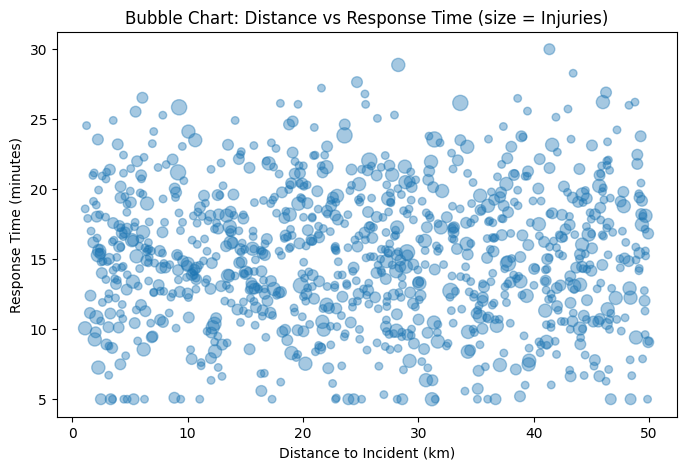

In [26]:
# Bubble Chart: Distance vs Response Time, bubble size = Number of Injuries
sample = df.sample(1000, random_state=42)
plt.figure(figsize=(8, 5))
plt.scatter(sample['Distance_to_Incident'], sample['Response_Time'],
            s=sample['Number_of_Injuries'] * 30, alpha=0.4)
plt.title('Bubble Chart: Distance vs Response Time (size = Injuries)')
plt.xlabel('Distance to Incident (km)')
plt.ylabel('Response Time (minutes)')
plt.show()

## 8. Correlation Heatmap

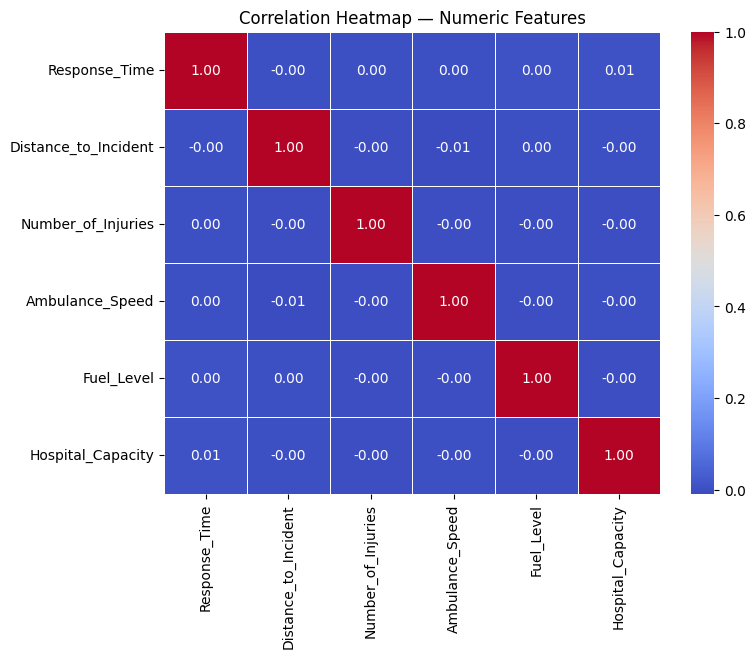

In [27]:
# Correlation matrix of numeric features
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features')
plt.show()

## 9. Contingency Table

In [28]:
# Contingency table: Incident Severity vs Weather Condition
contingency_table = pd.crosstab(df['Incident_Severity'], df['Weather_Condition'])
print('Contingency Table: Incident Severity vs Weather Condition')
contingency_table

Contingency Table: Incident Severity vs Weather Condition


Weather_Condition,Clear,Rainy,Stormy
Incident_Severity,,,
High,8520,1553,538
Low,50497,9444,3117
Medium,25194,4702,1555


In [29]:
# Contingency table: Traffic Congestion vs Region Type
contingency_table2 = pd.crosstab(df['Traffic_Congestion'], df['Region_Type'])
print('Contingency Table: Traffic Congestion vs Region Type')
contingency_table2

Contingency Table: Traffic Congestion vs Region Type


Region_Type,Rural,Suburban,Urban
Traffic_Congestion,,,
High,1064,2167,7425
Low,5204,10407,36782
Moderate,4164,8514,29393


## 10. Time Series Analysis — SMA and EMA

In [ ]:
# Monthly average Response Time as time series
monthly_rt_vals = monthly_rt.reset_index()
monthly_rt_vals.columns = ['YearMonth', 'Response_Time']
monthly_rt_vals['YearMonth'] = monthly_rt_vals['YearMonth'].astype(str)

rt_series = monthly_rt_vals['Response_Time']

# SMA with window = 3
sma_3 = rt_series.rolling(window=3).mean()
#EMA_today = α·value_today + (1−α)·EMA_yesterday

# EMA with alpha = 0.4
ema_4 = rt_series.ewm(alpha=0.4, adjust=False).mean()

print('SMA (3-month):')
print(sma_3.round(4).to_string())

SMA (3-month):
0         NaN
1         NaN
2     15.1497
3     15.0708
4     15.0420
5     15.0046
6     15.0700
7     15.0695
8     15.0546
9     15.0103
10    15.0280
11    15.0418
12    15.0566
13    15.0619
14    15.0975
15    15.0280
16    15.0535
17    15.0252
18    15.0951
19    15.0667
20    15.1037
21    15.0960
22    15.1166
23    15.0798


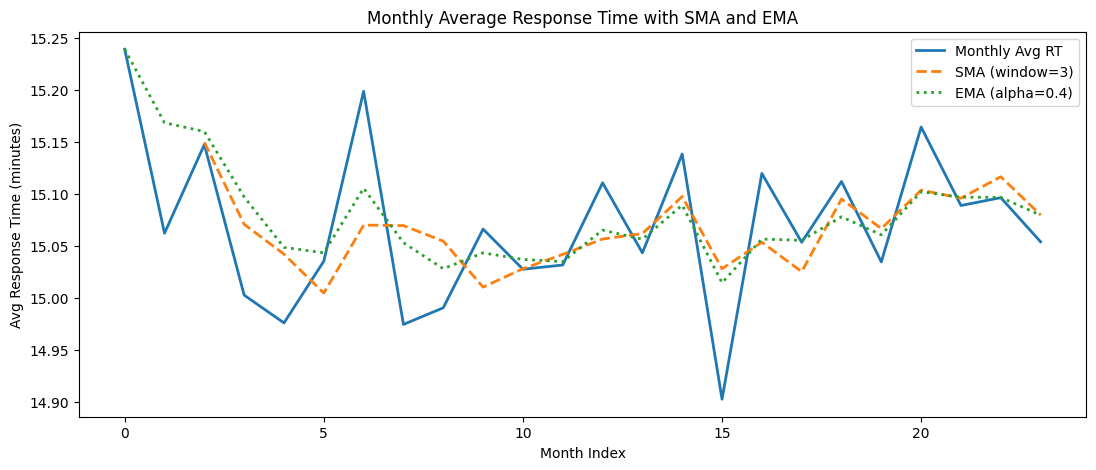

In [31]:
# Plot SMA and EMA
plt.figure(figsize=(13, 5))
plt.plot(rt_series.values, label='Monthly Avg RT', linewidth=2)
plt.plot(sma_3.values, label='SMA (window=3)', linestyle='--', linewidth=2)
plt.plot(ema_4.values, label='EMA (alpha=0.4)', linestyle=':', linewidth=2)
plt.title('Monthly Average Response Time with SMA and EMA')
plt.xlabel('Month Index')
plt.ylabel('Avg Response Time (minutes)')
plt.legend()
plt.show()

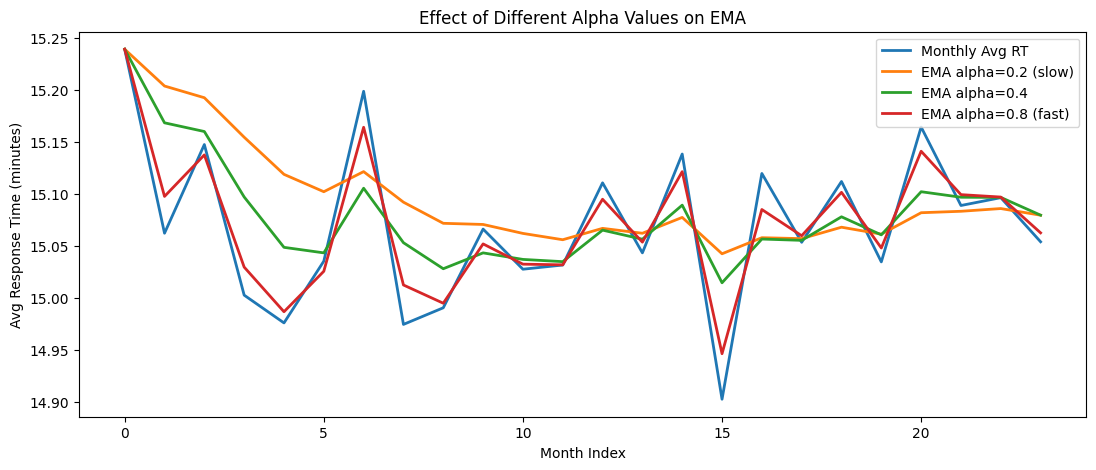

In [32]:
# Additional EMA with different alpha values
ema_2 = rt_series.ewm(alpha=0.2, adjust=False).mean()
ema_8 = rt_series.ewm(alpha=0.8, adjust=False).mean()

plt.figure(figsize=(13, 5))
plt.plot(rt_series.values, label='Monthly Avg RT', linewidth=2)
plt.plot(ema_2.values, label='EMA alpha=0.2 (slow)', linewidth=2)
plt.plot(ema_4.values, label='EMA alpha=0.4', linewidth=2)
plt.plot(ema_8.values, label='EMA alpha=0.8 (fast)', linewidth=2)
plt.title('Effect of Different Alpha Values on EMA')
plt.xlabel('Month Index')
plt.ylabel('Avg Response Time (minutes)')
plt.legend()
plt.show()